L. Parker and S. M. Christensen, *MathTensor: A System for Doing Tensor Analysis by Computer* (Addison-Wesley, 1994)

In [1]:
<< mTensor`

# Chapter 3. Symmetries, Operations, and Rules

## 3.1 Tensors and Their Symmetries

### 3.1.1 Indices

반대칭 텐서 $F_{ab}$를 정의한다. Covariant (또는 lower) 인덱스를 입력하기 위해 인덱스의 이름 앞에 'l'(ell)을 덧붙인다.

In [2]:
Tdefine[MaxwellF, "F", "-ba"];
MaxwellF[la, lb]

MaxwellF[la, lb]

한편 contravariant (또는 upper) 인덱스를 입력하려면 인덱스의 이름 앞에 'u'를 덧붙인다.

In [4]:
MaxwellF[ua, ub]

MaxwellF[ua, ub]

인덱스 이름으로 사용되도록 미리 준비된 인덱스들은 다음과 같다:

{la, lb, lc, ld, le, lf, lg, lh, li, lj, lk, ll, lm, ln, lo, lp, lq, lr, ls, lt, lu, lv, 
 
>   lw, lx, ly, lz, ua, ub, uc, ud, ue, uf, ug, uh, ui, uj, uk, ul, um, un, uo, up, uq, 
 
>   ur, us, ut, uu, uv, uw, ux, uy, uz}
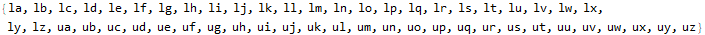

In [3]:
ShowIndices[]

In [5]:
{MaxwellF[lc, ld], MaxwellF[um, un]}

{MaxwellF[lc, ld], MaxwellF[um, un]}

### 3.1.2 Some Common Tensors

메트릭 텐서 $g_{ab}$, 리만 텐서 $R_{abc}^{\ \ \ \ \ d}$, 리치 텐서 $R_{ab}$, 스칼라 곡률 $R$ 등이 미리 정의되어 있다.

In [6]:
{Metricg[la, lb], RiemannCD[la, lb, lc, ud], 
 RicciCD[la, lb], ScalarCD[]}

{Metricg[la, lb], RiemannCD[la, lb, lc, ud], RicciCD[la, lb], ScalarCD[]}

### 3.1.3 Symmetries

전자기장 텐서 $F_{ab}$는 반대칭이고, 리치 텐서 $R_{ab}$는 대칭이다.

In [7]:
{MaxwellF[lb, la], RicciCD[lb, la]}

{MaxwellF[lb, la], RicciCD[lb, la]}

In [8]:
% // TindexSort

{-MaxwellF[la, lb], RicciCD[la, lb]}

리만 텐서의 대칭은 좀 더 복잡하다: $R_{abcd} = R_{[ab][cd]} = R_{cdab}$.

In [9]:
{RiemannCD[lb, la, lc, ld], RiemannCD[la, lb, ld, lc], 
  RiemannCD[lc, ld, la, lb]}

{RiemannCD[lb, la, lc, ld], RiemannCD[la, lb, ld, lc], RiemannCD[lc, ld, la, lb]}

In [10]:
% // TindexSort

{-RiemannCD[la, lb, lc, ld], -RiemannCD[la, lb, lc, ld], RiemannCD[la, lb, lc, ld]}

내부적으로 텐서 대칭은 순열의 Cycle 표기법과 대칭 또는 반대칭 값(+1 또는 -1)으로 저장되어 있다.

In [11]:
{GetSymmetry[MaxwellF], GetSymmetry[RicciCD]}

{GenSet[{Cycles[{{1, 2}}], -1}], GenSet[{Cycles[{{1, 2}}], 1}]}

In [12]:
GetSymmetry[RiemannCD]

GenSet[{Cycles[{{1, 2}}], -1}, {Cycles[{{3, 4}}], -1}, {Cycles[{{1, 3}, {2, 4}}], 1}]

사용자 입장에서는 텐서 대칭을 인덱스 교환 표기법으로 입력 또는 출력한다. 예를 들면, 반대칭인 전자기장의 대칭은 "-ba", 대칭인 리치 텐서의 대칭은 "+ba"로 입력하였다.

{Cycles[...], $\pm1$} 표기법를 인덱스 교환 표기법으로 바꿀 수 있다:

In [13]:
% // GStoString

-bacd-abdc+cdab

텐서 대칭은 유한군을 형성한다. 따라서 군론을 이용하여 모든 가능한 대칭을 구할 수 있다:

In [14]:
% // AllPermutations

+abcd-abdc-bacd+badc+cdab-cdba-dcab+dcba

### 3.1.4 Defining Your Own Tensors

이름이 `anti`이고 `a`로 출력되는 랭크 2인 반대칭 텐서를 정의한다:

In [15]:
Tdefine[anti, "a", "-ba"];
anti[lb, la]

anti[lb, la]

In [17]:
% // TindexSort

-anti[la, lb]

텐서 대칭의 내부 표현을 얻는다:

In [18]:
GetSymmetry[anti]

GenSet[{Cycles[{{1, 2}}], -1}]

인덱스 교환 표기법으로 바꾼다:

In [19]:
% // GStoString

-ba

텐서 `anti`의 모든 가능한 대칭을 구한다:

In [20]:
% // AllPermutations

+ab-ba

텐서를 정의할 때 대칭이 모순되면 오류 메시지를 출력한다:

In [21]:
Tdefine[wrong, "w", "ba-ba"]

`1` is not a valid `2`.: ba-ba is not a valid perm; it has inconsistent weights.

오류가 발생하면 그 텐서는 정의되지 않는다. (주의: 주피터 노트북에서는 Message의 출력이 제대로 동작하지 않는다.)

In [22]:
wrong[la, lb]

wrong[la, lb]

기존 텐서의 대칭을 갖는 새로운 텐서를 정의할 수 있다. 리만 텐서의 대칭을 갖는 텐서를 정의해 보자:

리만 텐서 대칭의 내부 표현을 얻는다:

In [26]:
GetSymmetry[RiemannCD]

GenSet[{Cycles[{{1, 2}}], -1}, {Cycles[{{3, 4}}], -1}, {Cycles[{{1, 3}, {2, 4}}], 1}]

인댁스 교환 표기법으로 바꾼다:

In [27]:
% // GStoString

-bacd-abdc+cdab

이름이 `newRiemannr`, 출력은 `r`, 대칭은 리만 텐서의 대칭을 갖는 새로운 텐서를 정의한다:

In [28]:
Tdefine[newRiemannr, "r", GStoString[GetSymmetry[RiemannCD]]]

In [29]:
newRiemannr[ld, lc, lb, la]

newRiemannr[ld, lc, lb, la]

In [30]:
% // TindexSort

newRiemannr[la, lb, lc, ld]

대칭이 없는 랭크 2와 랭크 1인 텐서를 정의한다:

In [31]:
Tdefine[w, 2]; Tdefine[v, 1]

In [32]:
{w[lb, la], w[uc, la], v[la], v[ua]}

{w[lb, la], w[uc, la], v[la], v[ua]}

랭크 2인 대칭 텐서를 정의한다:

In [33]:
Tdefine[q, "ba"];
q[lb, la]

q[lb, la]

In [35]:
% // TindexSort

q[la, lb]

랭크 2인 반대칭 텐서 `p`와 `t`를 정의한다:

In [36]:
Tdefine[{p, t}, "-ba"];
{p[lb, la], t[lb, la]}

{p[lb, la], t[lb, la]}

In [38]:
% // TindexSort

{-p[la, lb], -t[la, lb]}

이름이 `cyc`, 출력이 `c`, 그리고 순환 대칭을 갖는 텐서를 정의한다:

In [39]:
Tdefine[cyc, "c", "cab"]

In [40]:
{cyc[lc, la, lb], cyc[la, lb, lc], cyc[lb, lc, la]}

{cyc[lc, la, lb], cyc[la, lb, lc], cyc[lb, lc, la]}

In [41]:
% // TindexSort

{cyc[la, lb, lc], cyc[la, lb, lc], cyc[la, lb, lc]}

## 3.2 Contraction and the Metric Tensor

### 3.2.1 Forming New Tensors by Contraction

In [42]:
Tdefine[anti, "a", "-ba"]

In [48]:
anti[la, lb] anti[ua, lc]

anti[la, lb] anti[ua, lc]

In [49]:
% + anti[lb, ld] anti[lc, ud]

anti[lb, ld] anti[lc, ud] + anti[la, lb] anti[ua, lc]

In [50]:
Off[AutoFlag]

Contracted 인덱스를 더미 인덱스로 바꾸는 명령은 `Dum`이다.

In [51]:
%% // Dum

anti[l$4, lb] anti[u$4, lc] + anti[lb, l$3] anti[lc, u$3]

더미 인덱스를 정규 인덱스로 재명명한다:

In [52]:
% // ResetDummies

anti[lb, la] anti[lc, ua] + anti[la, lb] anti[ua, lc]

`AutoFlag`이 `On`이면 `ResetDummies`를 포함한 몇 가지 연산이 자동적으로 적용된다.

In [53]:
On[AutoFlag]  (* default *)

In [54]:
%% // TindexSort

2 anti[la, lb] anti[ua, lc]

### 3.2.2 Raising and Lowering Indices with the Metric Tensor

이름이 `Metricg`이고 출력이 `g`인 메트릭 텐서가 기본적으로 정의되어 있다.

In [55]:
Metricg[ua, ub] anti[lb, lc]

anti[lb, lc] Metricg[ua, ub]

메트릭을 이용하여 contracted 인덱스를 올린다:

In [56]:
% // Absorbg

anti[ua, lc]

메트릭은 대칭 텐서이다.

In [57]:
Metricg[lb, la]

Metricg[lb, la]

In [58]:
% // TindexSort

Metricg[la, lb]

메트릭의 인덱스가 (up, down) 또는 (down, up)이면 크로네커 델타이다.

In [59]:
Metricg[la, ub]

Kdelta[la, ub]

크로네커 델타를 통한 contracted 인덱스의 재조정은 자동적으로 적용된다.

In [60]:
Metricg[la, ub] RicciCD[lb, lc]

RicciCD[la, lc]

In [61]:
Metricg[ua, ub] Metricg[lb, lc]

Metricg[lb, lc] Metricg[ua, ub]

In [62]:
% // Absorbg

Kdelta[ua, lc]

리치 텐서의 정의: $R_{ab} \equiv R_{acb}^{\ \ \ \ \ c}$

In [63]:
Metricg[uc, ud] RiemannCD[la, lc, lb, ld] // Absorbg

RicciCD[la, lb]

스칼라 곡률의 정의: $R \equiv R_a^{\ a}$

In [64]:
Metricg[ua, ub] RicciCD[la, lb] // Absorbg

ScalarCD[]

### 3.2.3 Preventing Automatic Absorption of the Metric

`MathTensor`에서는 모든 텐서 표현에 `Absorbg`가 자동적으로 적용되지만, `mTensor`에서는 명시적으로 적용시켜야 한다. 단, 크로네커 델타를 통한 contracted 인덱스의 재조정은 디폴트인 경우 자동적으로 적용된다.

In [65]:
Metricg[ua, ub] anti[lb, lc]

anti[lb, lc] Metricg[ua, ub]

In [66]:
% // Absorbg

anti[ua, lc]

In [69]:
Metricg[la, lb] (RicciCD[ub, uc] + anti[ub, uc])

anti[ub, uc] Metricg[la, lb] + Metricg[la, lb] RicciCD[ub, uc]

In [70]:
% // Absorbg

anti[la, uc] + RicciCD[la, uc]

`Absorbg[expr]`은 `Absorb[expr, Metricg]`와 같다.

In [71]:
Tdefine[someG, "G", "ba"];
someG[li, lj]

someG[li, lj]

In [73]:
RicciCD[li, lj] someG[ui, uj]

RicciCD[li, lj] someG[ui, uj]

In [74]:
Absorb[%, someG]

ScalarCD[]

## 3.3 Simplification

### 3.3.1 Methods of Simplifying Tensor Expressions

In [2]:
expr1 = RicciCD[ua, ub] RiemannCD[la, li, lb, lj] + 
  RicciCD[ua, ub] RiemannCD[la, lj, lb, li]

RicciCD[ua, ub] RiemannCD[la, li, lb, lj] + RicciCD[ua, ub] RiemannCD[la, lj, lb, li]

In [3]:
expr2 = RiemannCD[la, lb, lc, ld] RiemannCD[ua, ub, ue, uf] RiemannCD[
    uc, ud, le, lf] + 
  RiemannCD[lc, ld, ug, uh] RiemannCD[le, lf, lg, lh] RiemannCD[uc, 
    ud, ue, uf]

RiemannCD[la, lb, lc, ld] RiemannCD[ua, ub, ue, uf] RiemannCD[uc, ud, le, lf] + 
 
>   RiemannCD[lc, ld, ug, uh] RiemannCD[le, lf, lg, lh] RiemannCD[uc, ud, ue, uf]

In [4]:
expr3 = RicciCD[la, lc] RicciCD[lb, uc] RicciCD[ua, ub] + 
  RicciCD[la, lb] RicciCD[ua, lc] RicciCD[ub, uc]

RicciCD[la, lc] RicciCD[lb, uc] RicciCD[ua, ub] + 
 
>   RicciCD[la, lb] RicciCD[ua, lc] RicciCD[ub, uc]

In [5]:
expr4 = RiemannCD[ua, ub, uc, ud] RiemannCD[la, lb, lc, ld] + 
  RiemannCD[ua, uc, ub, ud] RiemannCD[la, lc, lb, ld]

RiemannCD[la, lb, lc, ld] RiemannCD[ua, ub, uc, ud] + 
 
>   RiemannCD[la, lc, lb, ld] RiemannCD[ua, uc, ub, ud]

더미 인덱스의 이름은 중요하지 않으므로 재명명할 수 있다.

In [6]:
expr4 // Dum

2 RiemannCD[la, lb, lc, ld] RiemannCD[ua, ub, uc, ud]

더미 인덱스의 이름을 재명명하는 것만으로는 텐서 표현을 단순화(simplification)할 수 없다. 텐서의 대칭도 고려해야 한다.

In [7]:
expr1 // Dum

RicciCD[ua, ub] RiemannCD[la, li, lb, lj] + RicciCD[ua, ub] RiemannCD[la, lj, lb, li]

### 3.3.2 Simplifying with Symmetries

In [11]:
Tdefine[anti, "a", "-ba"]

이름이 `sym`이고 출력은 `s`인 대칭 텐서를 정의한다:

In [8]:
Tdefine[sym, "s", "ba"]

반대칭 텐서와 대칭 텐서의 contraction은 `0`이다.

In [12]:
anti[la, lb] sym[ua, ub]

anti[la, lb] sym[ua, ub]

In [13]:
% // Tsimplify

0

반대칭 텐서의 trace는 `0`이다.

In [14]:
anti[la, ua]

anti[la, ua]

In [15]:
% // Tsimplify

0

`Tsimplify`는 텐서 대칭을 고려하여 단순화한다.

In [16]:
anti[lb, ld] sym[lc, ub] - anti[ld, ub] sym[lb, lc]

-(anti[ld, ub] sym[lb, lc]) + anti[lb, ld] sym[lc, ub]

In [17]:
% // Tsimplify

-2 anti[ld, la] sym[lc, ua]

In [18]:
m anti[lb, ld] sym[lc, ub] + n anti[ld, ub] sym[lb, lc]

n anti[ld, ub] sym[lb, lc] + m anti[lb, ld] sym[lc, ub]

In [19]:
% // Tsimplify

-(m anti[ld, la] sym[lc, ua]) + n anti[ld, la] sym[lc, ua]

`MathTensor`의 `Tsimplify`는 패턴 매칭 방법을 사용하고, `mTensor`는 정규화(canonicalization) 방법을 사용한다. (내부적으로는 Mathematica 버전9 이후의 `TensorReduce`를 사용한다.) 그런데 패턴 매칭 방법을 이용한 단순화는 실질적으로 사용하기에 상당히 비효율적이다. 따라서 텐서 표현의 단순화는 정규화 방법을 사용하는 것이 기본이다. 여기서는 역사적 이유와 두 방법의 비교를 위해 패턴 매칭 방법을 사용한 단순화도 사용해 본다.

In [20]:
%% // TsimplifyPatternMatching

(-m + n) anti[ld, lb] sym[ub, lc]

In [21]:
expr = expr3 + expr4

RicciCD[la, lc] RicciCD[lb, uc] RicciCD[ua, ub] + 
 
>   RicciCD[la, lb] RicciCD[ua, lc] RicciCD[ub, uc] + 
 
>   RiemannCD[la, lb, lc, ld] RiemannCD[ua, ub, uc, ud] + 
 
>   RiemannCD[la, lc, lb, ld] RiemannCD[ua, uc, ub, ud]

In [22]:
% // Tsimplify

2 RicciCD[la, lb] RicciCD[ua, lc] RicciCD[ub, uc] + 
 
>   2 RiemannCD[la, lb, lc, ld] RiemannCD[ua, ub, uc, ud]

In [23]:
expr2

RiemannCD[la, lb, lc, ld] RiemannCD[ua, ub, ue, uf] RiemannCD[uc, ud, le, lf] + 
 
>   RiemannCD[lc, ld, ug, uh] RiemannCD[le, lf, lg, lh] RiemannCD[uc, ud, ue, uf]

In [24]:
% // Tsimplify

2 RiemannCD[la, lb, lc, ld] RiemannCD[ua, ub, le, lf] RiemannCD[uc, ud, ue, uf]

In [25]:
%% // TsimplifyPatternMatching // Timing

{9.48438, 2 RiemannCD[la, lb, lc, ld] RiemannCD[ua, ub, le, lf] 
 
>    RiemannCD[uc, ud, ue, uf]}

명백하게 패턴 매칭 방법을 이용한 단순화는 매우 비효율적이다.

### 3.3.3 Simplifying Traces and Contractions of Products

In [26]:
Tdefine[nosym1, "ns1", 2];
Tdefine[nosym2, "ns2", 2];
Tdefine[nosym3, "ns3", 2]

아래의 두 항은 더미 인덱스의 이름만 제외하면 동일하다.

In [29]:
expr = nosym1[la, ub] nosym2[lb, uc] nosym3[lc, ua] + 
  nosym3[la, ub] nosym1[lb, uc] nosym2[lc, ua]

nosym1[lb, uc] nosym2[lc, ua] nosym3[la, ub] + 
 
>   nosym1[la, ub] nosym2[lb, uc] nosym3[lc, ua]

In [30]:
% // Dum

2 nosym1[la, ub] nosym2[lb, uc] nosym3[lc, ua]

In [31]:
%% // Tsimplify

2 nosym1[la, lb] nosym2[ub, lc] nosym3[uc, ua]

In [32]:
Tdefine[n, 4]

아래 표현의 단순화에는 `TsimplifyPatternMatching`도 `Tsimplify` 만큼 효율적이다:

In [33]:
n[ua, ub, lc, ld] n[uc, ud, le, lh] n[ue, uf, lg, lf] n[ug, uh, la, 
   lb] - n[ua, ub, lc, ld] n[uc, ud, le, lf] n[ue, uf, lg, lb] n[ug, 
   uh, la, lh]

n[ua, ub, lc, ld] n[uc, ud, le, lh] n[ue, uf, lg, lf] n[ug, uh, la, lb] - 
 
>   n[ua, ub, lc, ld] n[uc, ud, le, lf] n[ue, uf, lg, lb] n[ug, uh, la, lh]

In [34]:
% // Dum

-(n[ua, ub, lc, ld] n[uc, ud, le, lf] n[ue, uf, lg, lb] n[ug, uh, la, lh]) + 
 
>   n[ua, ub, lc, ld] n[uc, ud, le, lf] n[ue, ug, lh, lg] n[uh, uf, la, lb]

In [35]:
%% // Tsimplify

0

In [36]:
%%% // TsimplifyPatternMatching

0

텐서 표현의 단순화는 `Tsimplify` 명령 하나만 사용해도 충분함을 알 수 있다.

### 3.3.4 Canonical Ordering of Indices

mTensor에서 `Tsimplify`는 Mathematica의 `TensorReduce` 명령을 내부적으로 사용한다. 그런데 `TensorReduce`는 본질적으로 정규화(canonicalization) 방법을 사용한다.

In [37]:
expr2

RiemannCD[la, lb, lc, ld] RiemannCD[ua, ub, ue, uf] RiemannCD[uc, ud, le, lf] + 
 
>   RiemannCD[lc, ld, ug, uh] RiemannCD[le, lf, lg, lh] RiemannCD[uc, ud, ue, uf]

In [38]:
expr2 // Tsimplify

2 RiemannCD[la, lb, lc, ld] RiemannCD[ua, ub, le, lf] RiemannCD[uc, ud, ue, uf]

In [39]:
expr2 // TsimplifyPatternMatching // Timing

{9.46875, 2 RiemannCD[la, lb, lc, ld] RiemannCD[ua, ub, le, lf] 
 
>    RiemannCD[uc, ud, ue, uf]}

In [40]:
expr3

RicciCD[la, lc] RicciCD[lb, uc] RicciCD[ua, ub] + 
 
>   RicciCD[la, lb] RicciCD[ua, lc] RicciCD[ub, uc]

In [41]:
expr3 // Tsimplify

2 RicciCD[la, lb] RicciCD[ua, lc] RicciCD[ub, uc]

In [42]:
expr3 // TsimplifyPatternMatching // Timing

{0.078125, 2 RicciCD[la, lc] RicciCD[lb, uc] RicciCD[ua, ub]}

`TsimplifyPatternMatching`은 텐서의 대칭이 커질수록 비효율적임을 알 수 있다.

## 3.4 Operations on Tensors

### 3.4.1 Symmetrization and Antisymmetrization

리만 텐서의 첫 번째와 세 번째 인덱스를 대칭화와 반대칭화한다:

RiemannCD[la, lb, lc, ld]   RiemannCD[lc, lb, la, ld]
------------------------- + -------------------------
            2                           2
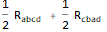

In [43]:
SymmetrizeIndices[{la, lc}, RiemannCD[la, lb, lc, ld]]

RiemannCD[la, lb, lc, ld]   RiemannCD[lc, lb, la, ld]
------------------------- - -------------------------
            2                           2
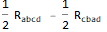

In [44]:
AntisymmetrizeIndices[{la, lc}, RiemannCD[la, lb, lc, ld]]

리만 텐서의 처음 두 인덱스는 반대칭이므로 대칭화하면 `0`이 된다:

RiemannCD[la, lb, lc, ld]   RiemannCD[lb, la, lc, ld]
------------------------- + -------------------------
            2                           2
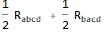

In [45]:
SymmetrizeIndices[{la, lb}, RiemannCD[la, lb, lc, ld]]

In [46]:
% // TindexSort

0

RiemannCD[la, lb, lc, ld]   RiemannCD[lb, la, lc, ld]
------------------------- - -------------------------
            2                           2
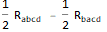

In [47]:
AntisymmetrizeIndices[{la, lb}, RiemannCD[la, lb, lc, ld]]

In [48]:
% // TindexSort

RiemannCD[la, lb, lc, ld]

반대칭 텐서 `MaxwellF`를 정의하고, 인덱스 `a`, `b`, `c`를 반대칭화한다:

In [49]:
Tdefine[MaxwellF, "F", "-ba"]

MaxwellF[lb, lc] RicciCD[la, ld]   MaxwellF[lc, lb] RicciCD[la, ld]
-------------------------------- - -------------------------------- - 
               6                                  6
 
    MaxwellF[la, lc] RicciCD[lb, ld]   MaxwellF[lc, la] RicciCD[lb, ld]
>   -------------------------------- + -------------------------------- + 
                   6                                  6
 
    MaxwellF[la, lb] RicciCD[lc, ld]   MaxwellF[lb, la] RicciCD[lc, ld]
>   -------------------------------- - --------------------------------
                   6                                  6
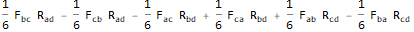

In [50]:
AntisymmetrizeIndices[{la, lb, lc}, MaxwellF[la, lb] RicciCD[lc, ld]]

MaxwellF[lb, lc] RicciCD[la, ld]   MaxwellF[la, lc] RicciCD[lb, ld]
-------------------------------- - -------------------------------- + 
               3                                  3
 
    MaxwellF[la, lb] RicciCD[lc, ld]
>   --------------------------------
                   3
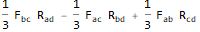

In [51]:
% // TindexSort

랭크-4 텐서를 정의한 후, 완전 대칭(totally symmetric)으로 설정한다:

In [52]:
Tdefine[tens, 4];
SetSymmetry[tens, "4+"]

물론 텐서를 정의하면서 인덱스 대칭을 지정할 수 있다:

In [54]:
Tdefine[tens, "4+"]

In [55]:
tens[ld, lc, lb, la] // TindexSort

tens[la, lb, lc, ld]

텐서의 대칭을 완전 반대칭(totally anti-symmetric)으로 설정한다:

In [56]:
SetSymmetry[tens, "4-"]

In [57]:
tens[ld, lb, lc, la] // TindexSort

-tens[la, lb, lc, ld]

### 3.4.2 Differential Form Operations

#### 외미분(Exterior Derivative)

2-form 을 정의한다:

In [58]:
Fdefine[w2, 2]

In [59]:
XD[w2]

XD[w2[]]

2-form $w_2$의 외미분인 3-form $dw_2$를 IndexedTensor 표현으로 바꾼다:

In [60]:
ToTensor[%, {la, lb, lc}]

CD[la, w2[lb, lc]] - CD[lb, w2[la, lc]] + CD[lc, w2[la, lb]]

공변 도함수 $\nabla_a$를 보통 도함수 $\partial_a$로 바꾼다:

In [61]:
% // CDtoGamma

BD[la, w2[lb, lc]] - BD[lb, w2[la, lc]] + BD[lc, w2[la, lb]] + 
 
>   GammaCD[lb, lc, ud] w2[la, ld] - GammaCD[lc, lb, ud] w2[la, ld] - 
 
>   GammaCD[la, lc, ud] w2[lb, ld] - GammaCD[lc, la, ud] w2[ld, lb] - 
 
>   GammaCD[la, lb, ud] w2[ld, lc] + GammaCD[lb, la, ud] w2[ld, lc]

In [62]:
% // Tsimplify

BD[la, w2[lb, lc]] - BD[lb, w2[la, lc]] + BD[lc, w2[la, lb]]

외미분을 IndexedTensor 표현으로 바꿀 때 공변 도함수 대신 보통 도함수를 사용할 수 있게 한다:

In [63]:
Off[XDtoCDfrag]

In [64]:
ToTensor[XD[w2], {la, lb, lc}]

BD[la, w2[lb, lc]] - BD[lb, w2[la, lc]] + BD[lc, w2[la, lb]]

In [65]:
On[XDtoCDfrag]  (* default *)

1-form과 3-form을 정의한다:

In [66]:
Fdefine[{w1, w3}, {1, 3}]

공간을 3차원으로 설정한다:

In [16]:
SetDimension[3]

3-form의 외미분은 4-form이고, 3차원 공간에서는 `0`이다.

In [69]:
XD[w3]

0

#### 외적(Exterior Product)

1-form과 2-form의 외적은 3-form이다.

In [70]:
XP[w1, w2]

XP[w1, w2]

In [71]:
% // XD

0

1-form을 정의한다:

In [72]:
Fdefine[s1, 1]

In [73]:
XP[s1, w1]

XP[s1, w1]

In [74]:
% // XD

-XP[s1, XD[w1[]]] + XP[w1, XD[s1[]]]

#### HodgeStar

3차원에서 $w_1$의 Hodge dual은 2-form이다.

In [75]:
HodgeStar[w1]

HodgeStar[w1]

In [76]:
ToTensor[%, {la, lb}]

Epsilon[uc, la, lb] w1[lc]

#### 좌표 표현

Indexed 0-Form을 정의한다:

In [2]:
Fdefine[x[ua], 0]

성분값을 지정한다:

In [3]:
SetComponents[
 x[ua], {r Sin[\[Theta]] Cos[\[Phi]], r Sin[\[Theta]] Sin[\[Phi]], 
  r Cos[\[Theta]]}]

In [4]:
{x[1], x[2], x[3]}

{r Cos[ϕ] Sin[θ], r Sin[θ] Sin[ϕ], r Cos[θ]}

구형 좌표계에 대한 외미분 규칙:

In [5]:
xdRule = {XD[Sin[\[Theta]_]] :> Cos[\[Theta]] XD[\[Theta]], 
   XD[Cos[\[Theta]_]] :> -Sin[\[Theta]] XD[\[Theta]]}

{XD[Sin[θ_]] :> Cos[θ] XD[θ], XD[Cos[θ_]] :> -(Sin[θ] XD[θ])}

In [6]:
dx1 = XD[x[1]] /. xdRule

Cos[ϕ] Sin[θ] XD[r] + r Cos[θ] Cos[ϕ] XD[θ] - r Sin[θ] Sin[ϕ] XD[ϕ]

In [7]:
dx2 = XD[x[2]] /. xdRule

Sin[θ] Sin[ϕ] XD[r] + r Cos[θ] Sin[ϕ] XD[θ] + r Cos[ϕ] Sin[θ] XD[ϕ]

In [8]:
dx3 = XD[x[3]] /. xdRule

Cos[θ] XD[r] - r Sin[θ] XD[θ]

$x^3$ 방향에 수직한 면적 요소:

In [9]:
dArea3 = XP[dx1, dx2] // Simplify

2                     2
r Sin[θ]  XP[XD[r], XD[ϕ]] + r  Cos[θ] Sin[θ] XP[XD[θ], XD[ϕ]]

체적 요소:

In [10]:
dVolume = XP[dx1, dx2, dx3]

2       2       2
r  Cos[θ]  Cos[ϕ]  Sin[θ] XP[XD[r], XD[θ], XD[ϕ]] + 
 
     2       2       3
>   r  Cos[ϕ]  Sin[θ]  XP[XD[r], XD[θ], XD[ϕ]] + 
 
     2       2              2
>   r  Cos[θ]  Sin[θ] Sin[ϕ]  XP[XD[r], XD[θ], XD[ϕ]] + 
 
     2       3       2
>   r  Sin[θ]  Sin[ϕ]  XP[XD[r], XD[θ], XD[ϕ]]

In [11]:
% // Simplify

2
r  Sin[θ] XP[XD[r], XD[θ], XD[ϕ]]

#### 내적(Interior Product)

1-form, 2-form, Indexed 0-form을 정의한다:

In [12]:
Fdefine[{w1, w2}, {1, 2}]; Fdefine[x[ua], 0]

구형 좌표계를 설정한다:

In [13]:
SetComponents[x[ua], {r, \[Theta], \[Phi]}]

$w_2$의 좌표 표현을 얻는다:

w2[la, lb] XP[XD[x[ua]], XD[x[ub]]]
-----------------------------------
                 2
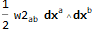

In [17]:
1/2 ToTensor[w2, {la, lb}] XP[XD[x[ua]], XD[x[ub]]]

In [18]:
% // SumDum // TindexSort

w2[-1, -2] XP[XD[r], XD[θ]] + w2[-1, -3] XP[XD[r], XD[ϕ]] + w2[-2, -3] XP[XD[θ], XD[ϕ]]

In [20]:
CoordRep[w2, {r, \[Theta], \[Phi]}]

w2[-1, -2] XP[XD[r], XD[θ]] + w2[-1, -3] XP[XD[r], XD[ϕ]] + w2[-2, -3] XP[XD[θ], XD[ϕ]]

$dw_1$의 좌표 표현을 얻는다:

CD[la, w1[lb]] XP[XD[x[ua]], XD[x[ub]]]   CD[lb, w1[la]] XP[XD[x[ua]], XD[x[ub]]]
--------------------------------------- - ---------------------------------------
                   2                                         2
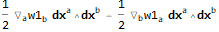

In [21]:
1/2 ToTensor[XD[w1], {la, lb}] XP[XD[x[ua]], XD[x[ub]]]

In [22]:
% // SumDum // TindexSort // CollectForm

(-CD[-2, w1[-1]] + CD[-1, w1[-2]]) XP[XD[r], XD[θ]] + 
 
>   (-CD[-3, w1[-1]] + CD[-1, w1[-3]]) XP[XD[r], XD[ϕ]] + 
 
>   (-CD[-3, w1[-2]] + CD[-2, w1[-3]]) XP[XD[θ], XD[ϕ]]

In [23]:
CoordRep[XD[w1], {r, \[Theta], \[Phi]}]

(-CD[-2, w1[-1]] + CD[-1, w1[-2]]) XP[XD[r], XD[θ]] + 
 
>   (-CD[-3, w1[-1]] + CD[-1, w1[-3]]) XP[XD[r], XD[ϕ]] + 
 
>   (-CD[-3, w1[-2]] + CD[-2, w1[-3]]) XP[XD[θ], XD[ϕ]]

$w_1$과 $dw_1$의 내적에 대한 좌표 표현:

In [24]:
IP[w1, XD[w1]]

IP[w1, XD[w1[]]]

In [25]:
Off[XDtoCDfrag]

In [26]:
ToTensor[%%, {la}] XD[x[ua]]

-(BD[la, w1[lb]] w1[ub] XD[x[ua]]) + BD[lb, w1[la]] w1[ub] XD[x[ua]]

In [27]:
% // SumDum // TindexSort // CollectForm

(BD[-2, w1[-1]] w1[2] - BD[-1, w1[-2]] w1[2] + BD[-3, w1[-1]] w1[3] - 
 
>      BD[-1, w1[-3]] w1[3]) XD[r] + 
 
>   (-(BD[-2, w1[-1]] w1[1]) + BD[-1, w1[-2]] w1[1] + BD[-3, w1[-2]] w1[3] - 
 
>      BD[-2, w1[-3]] w1[3]) XD[θ] + 
 
>   (-(BD[-3, w1[-1]] w1[1]) + BD[-1, w1[-3]] w1[1] - BD[-3, w1[-2]] w1[2] + 
 
>      BD[-2, w1[-3]] w1[2]) XD[ϕ]

In [28]:
CoordRep[IP[w1, XD[w1]], {r, \[Theta], \[Phi]}]

(BD[-2, w1[-1]] w1[2] - BD[-1, w1[-2]] w1[2] + BD[-3, w1[-1]] w1[3] - 
 
>      BD[-1, w1[-3]] w1[3]) XD[r] + 
 
>   (-(BD[-2, w1[-1]] w1[1]) + BD[-1, w1[-2]] w1[1] + BD[-3, w1[-2]] w1[3] - 
 
>      BD[-2, w1[-3]] w1[3]) XD[θ] + 
 
>   (-(BD[-3, w1[-1]] w1[1]) + BD[-1, w1[-3]] w1[1] - BD[-3, w1[-2]] w1[2] + 
 
>      BD[-2, w1[-3]] w1[2]) XD[ϕ]

In [29]:
On[XDtoCDfrag]  (* default *)

#### `DegreeForm`, `ZeroDegreeQ`

Indexed 2-Form을 정의한다:

In [102]:
Fdefine[h[ua], 2];
h[ua]

h[ua]

In [104]:
{DegreeForm[h[ua]], ZeroDegreeQ[h[ua]]}

{2, False}

In [105]:
ToTensor[h[ua], {lb, lc}]

h[lb, lc, ua]

2-form $h^a$를 IndexedTensor로 변환하였으므로 $h_{bc}^{\ \ \ a}$는 0-form이다.

In [106]:
{DegreeForm[h[lb, lc, ua]], ZeroDegreeQ[h[lb, lc, ua]]}

{0, True}

### 3.4.3 Levi-Civita Epsilon Tensor

Levi-Civita 텐서는 시공간의 차원과 동일한 수의 인덱스를 갖는 완전 반대칭 텐서이다.

시공간을 4차원으로 설정한다:

In [107]:
SetDimension[4]

In [108]:
Epsilon[lb, la, lc, ld] // TindexSort

-Epsilon[la, lb, lc, ld]

Levi-Civita 텐서의 성분 $\epsilon_{1234}$의 값을 지정한다. (나머지 성분은 완전 반대칭을 이용하여 자동으로 설정된다):

In [109]:
SetComponents[Epsilon[-1, -2, -3, -4], Sqrt[Abs[Detg]]]

In [110]:
Epsilon[-1, -2, -3, -4]

Sqrt[Abs[Detg]]

$p$-form에 대한 Dual 연산 (참고. R. M. Wald 문제 2-(a)):
\begin{gather*}
  ({}^*\alpha)_{b_1 \cdots b_{n-p}}
  = \frac{1}{p!} \alpha^{a_1 \cdots a_p}
  \epsilon_{a_1 \cdots a_p b_1 \cdots b_{n-p}} \\
  {}^{**} \alpha = (-1)^{\frac{n-s}{2} + p(n-p)} \alpha
\end{gather*}
여기서 $s$는 메트릭 signature이다.

In [111]:
Tdefine[MaxwellF, "F", "-ba"]

Epsilon[ua, ub, uc, ud] MaxwellF[la, lb]
----------------------------------------
                   2
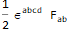

In [112]:
DualStar[MaxwellF[la, lb], {ua, ub, uc, ud}]

Epsilon[u$116, u$117, c, d] MaxwellF[l$116, l$117]
starF[c_, d_] :> DumFresh[--------------------------------------------------]
                                                  2
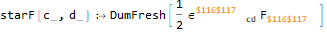

In [113]:
aRule = RuleUnique[starF[c_, d_], 
  1/2 Epsilon[ua, ub, c, d] MaxwellF[la, lb]]

Epsilon[uc, ud, ua, ub] MaxwellF[lc, ld]
----------------------------------------
                   2
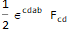

In [114]:
starF[ua, ub] /. aRule

Epsilon[uc, ud, la, lb] MaxwellF[lc, ld]
----------------------------------------
                   2
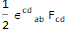

In [115]:
starF[la, lb] /. aRule

시공간의 metric signature를 설정한다:

In [116]:
SetSignature[2]

Epsilon[ua, ub, uc, ud] Epsilon[ue, uf, la, lb] MaxwellF[le, lf]
----------------------------------------------------------------
                               4
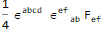

In [117]:
DualStar[starF[la, lb] /. aRule, {ua, ub, uc, ud}]

`EpsilonProductRule[]` (참고. R. M. Wald, Appendix B, Eq. (B.2.13)):
$$
  \epsilon^{a_1 \cdots a_j a_{j+1} \cdots a_n}
  \epsilon_{a_1 \cdots a_j b_{j+1} \cdots b_n}
  = (-1)^{\frac{n-s}{2}} (n-j)! j!
  \delta^{[a_{j+1}}_{b_{j+1}} \cdots
  \delta^{a_n]}_{b_{n}}
$$

MaxwellF[le, lf] Metricg[uc, uf] Metricg[ud, ue]
------------------------------------------------ - 
                       2
 
    MaxwellF[le, lf] Metricg[uc, ue] Metricg[ud, uf]
>   ------------------------------------------------
                           2
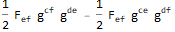

In [118]:
% /. EpsilonProductRule[]

-MaxwellF[uc, ud]   MaxwellF[ud, uc]
----------------- + ----------------
        2                  2
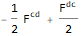

In [119]:
% // Absorbg

In [120]:
% // TindexSort

-MaxwellF[uc, ud]

시공간을 3차원 유클리드 공간의 특성들로 설정한다:

In [121]:
SetDimension[3]; SetSignature[3]; Detg = 1;

In [122]:
Tdefine[{s, v, w}, 1]

In [123]:
Epsilon[ua, lb, lc] s[ub] v[uc]

Epsilon[ua, lb, lc] s[ub] v[uc]

In [124]:
sRule = RuleUnique[sxv[a_], Epsilon[a, lb, lc] s[ub] v[uc]]

sxv[a_] :> DumFresh[Epsilon[a, l$124, l$125] s[u$124] v[u$125]]

벡터 외적에 대한 공식:
$$
  (\vec{s} \times \vec{v}) \times \vec{w}
  = (\vec{s} \cdot \vec{w}) \vec{v}
  - (\vec{v} \cdot \vec{w}) \vec{s}
$$

In [125]:
Epsilon[ua, lb, lc] (sxv[ub] /. sRule) w[uc]

Epsilon[ua, lb, lc] Epsilon[ub, ld, le] s[ud] v[ue] w[uc]

In [126]:
% /. EpsilonProductRule[]

Metricg[lc, ld] s[ud] v[ua] w[uc] - Metricg[lc, le] s[ua] v[ue] w[uc]

In [127]:
% // Absorbg

-(s[ua] v[lc] w[uc]) + s[lc] v[ua] w[uc]

### 3.4.4 Derivative Operators

In [4]:
Tdefine[MaxwellF, "F", "-ba"]

In [5]:
expr = RicciCD[la, lb] MaxwellF[ub, lc] + RicciCD[la, lc]

MaxwellF[ub, lc] RicciCD[la, lb] + RicciCD[la, lc]

#### 보통 도함수 $\partial_a$

In [6]:
BD[ld, %]

BD[ld, RicciCD[la, lc]] + BD[ld, RicciCD[la, lb]] MaxwellF[ub, lc] + 
 
>   BD[ld, MaxwellF[ub, lc]] RicciCD[la, lb]

In [7]:
BD[ld, le, expr]

BD[ld, BD[le, RicciCD[la, lc]]] + BD[ld, RicciCD[la, lb]] BD[le, MaxwellF[ub, lc]] + 
 
>   BD[ld, MaxwellF[ub, lc]] BD[le, RicciCD[la, lb]] + 
 
>   BD[ld, BD[le, RicciCD[la, lb]]] MaxwellF[ub, lc] + 
 
>   BD[ld, BD[le, MaxwellF[ub, lc]]] RicciCD[la, lb]

In [8]:
BD[la, lb, MaxwellF[ua, ub]]

BD[la, BD[lb, MaxwellF[ua, ub]]]

`Coordinate Basis`에서 보통 도함수의 연속된 미분 $\partial_a \partial_b$는 교환된다:

In [9]:
% // TindexSort

0

#### 공변 도함수 $\nabla_a$

In [10]:
CD[ld, expr]

CD[ld, RicciCD[la, lc]] + CD[ld, RicciCD[la, lb]] MaxwellF[ub, lc] + 
 
>   CD[ld, MaxwellF[ub, lc]] RicciCD[la, lb]

메트릭 $g_{ab}$는 공변 도함수 $\nabla_a$의 공변 상수이다:

In [11]:
CD[la, Metricg[lb, lc]]

0

전자기장 $F_{ab}$의 벡터 표텐셜 표현:

In [12]:
Tdefine[A[la]]

In [13]:
maxwellVectorPotentialRule = 
 RuleUnique[MaxwellF[a_, b_], CD[a, A[b]] - CD[b, A[a]]]

MaxwellF[a_, b_] :> DumFresh[CD[a, A[b]] - CD[b, A[a]]]

In [14]:
MaxwellF[la, lb] /. maxwellVectorPotentialRule

CD[la, A[lb]] - CD[lb, A[la]]

In [15]:
% // CDtoGamma

BD[la, A[lb]] - BD[lb, A[la]] - A[lc] GammaCD[la, lb, uc] + A[lc] GammaCD[lb, la, uc]

In [16]:
% // TindexSort

BD[la, A[lb]] - BD[lb, A[la]]

막스웰 방정식:

In [17]:
CD[lb, MaxwellF[ua, ub]]

CD[lb, MaxwellF[ua, ub]]

In [18]:
divF = % /. maxwellVectorPotentialRule

CD[lb, CD[ua, A[ub]]] - CD[lb, CD[ub, A[ua]]]

In [19]:
CommuteCD[{ua, lb}, %]

-CD[lb, CD[ub, A[ua]]] + CD[ua, CD[lb, A[ub]]] + A[ub] RicciCD[ua, lb]

In [20]:
lorentzGaugeRule = RuleUnique[CD[la_, A[ua_]], 0, PairIndexQ[la, ua]]

CD[la_, A[ua_]] :> DumFresh[0] /; PairIndexQ[la, ua]

In [21]:
%% /. lorentzGaugeRule

-CD[lb, CD[ub, A[ua]]] + A[ub] RicciCD[ua, lb]

#### Lie 도함수 $\mathcal{L}_v$

In [22]:
Tdefine[v, "a"]

In [23]:
LD[v, expr]

LD[v, RicciCD[la, lc]] + LD[v, RicciCD[la, lb]] MaxwellF[ub, lc] + 
 
>   LD[v, MaxwellF[ub, lc]] RicciCD[la, lb]

In [24]:
Tdefine[q, "ab"];
LD[v, q[ua, lb]]

LD[v, q[ua, lb]]

$$
  \mathcal{L}_v q^a_{\ \ b} = v^p \partial_p q^a_{\ \ b}
  - (\partial_p v^a) q^p_{\ \ b}
  + (\partial_b v^p) q^a_{\ \ p}
$$

In [26]:
% // LDtoCD

CD[lb, v[uc]] q[ua, lc] - CD[lc, v[ua]] q[uc, lb] + CD[lc, q[ua, lb]] v[uc]

In [27]:
% // CDtoGamma

BD[lb, v[uc]] q[ua, lc] - BD[lc, v[ua]] q[uc, lb] + BD[lc, q[ua, lb]] v[uc] - 
 
>   GammaCD[lc, lb, ud] q[ua, ld] v[uc] + GammaCD[lc, ld, ua] q[ud, lb] v[uc] + 
 
>   GammaCD[lb, ld, uc] q[ua, lc] v[ud] - GammaCD[lc, ld, ua] q[uc, lb] v[ud]

In [28]:
% // Tsimplify

BD[lb, v[uc]] q[ua, lc] - BD[lc, v[ua]] q[uc, lb] + BD[lc, q[ua, lb]] v[uc]

따라서 Lie 도함수는 메트릭과 무관하다.

## 3.5 Creating Rules and Definitions

### 3.5.1 Simple Definition and Rules

In [29]:
Tdefine[tx, "2"]; Tdefine[ty, "1"]

인덱스 `a`와 `b`가 contracted 인덱스일 때 `tx`에 자동적으로 적용되는 *전역적인* 변환 규칙을 생성한다:

In [30]:
tx[a_, b_] := ty[a] ty[b] /; PairIndexQ[a, b]

In [31]:
tx[ud, ld]

ty[ld] ty[ud]

In [32]:
tx[la, lb]

tx[la, lb]

`tx`에 정의된 특성을 제거한다:

In [38]:
RemoveObject[tx]; Tdefine[tx, "2"]

인덱스 `a`와 `b`가 contracted 인덱스일 때 `tx`에 적용되는 *지역적인* 변환 규칙을 생성한다:

In [39]:
txTotyRule := tx[a_, b_] :> ty[a] ty[b] /; PairIndexQ[a, b]

*지역적인* 변환 규칙은 명시적으로 적용해야 한다:

In [40]:
tx[le, ue] /. txTotyRule

ty[le] ty[ue]

In [41]:
tx[lb, uc] /. txTotyRule

tx[lb, uc]

In [42]:
tx[le, ue] tx[lb, uc] /. txTotyRule

tx[lb, uc] ty[le] ty[ue]

In [43]:
tx[le, ue] tx[lf, uf] /. txTotyRule

ty[le] ty[lf] ty[ue] ty[uf]

### 3.5.2 Pitfalls of Dummy Indices

변환 규칙에 contracted 인덱스가 포함되어 있으면 문제가 발생할 수 있다.

In [44]:
txTotyRule2 := 
 tx[a_, b_] :> ty[a] ty[b] ty[lc] ty[uc] /; PairIndexQ[a, b]

In [45]:
tx[le, ue] /. txTotyRule2

ty[lc] ty[le] ty[uc] ty[ue]

In [46]:
tx[le, ue] tx[lf, uf] /. txTotyRule2

2                     2
ty[lc]  ty[le] ty[lf] ty[uc]  ty[ue] ty[uf]

이러한 문제는 contracted 인덱스를 더미 인덱스로 만드는 `Dum` 명령을 사용해서 일시적으로는 회피할 수 있다:

In [47]:
(Dum[tx[le, ue] /. txTotyRule2]) (Dum[tx[lf, uf] /. txTotyRule2])

ty[la] ty[lb] ty[lc] ty[ld] ty[ua] ty[ub] ty[uc] ty[ud]

또 다른 문제가 발생하는 상황을 알아 보자:

In [48]:
Tdefine[tv, "ab"]

In [49]:
tvTotxRule := tv[a_, b_] :> 2 tx[a, b]

In [50]:
rule = {tvTotxRule, txTotyRule2}

{tv[a_, b_] :> 2 tx[a, b], tx[a_, b_] :> ty[a] ty[b] ty[lc] ty[uc] /; PairIndexQ[a, b]}

발생하는 문제를 명확히 보기 위해 문법을 확인해 보자:

In [51]:
On[SyntaxCheckFlag]

In [52]:
tv[la, ua] //. rule

2 ty[la] ty[lc] ty[ua] ty[uc]

In [53]:
tv[la, ua] tv[lb, ub] //. rule

`1` `2` `3` `4`: non-scalar expression ty[lc]  

`1` `2` `3` `4`: non-scalar expression ty[uc]  

ty[la] ty[lb] ty[ua] ty[ub] ErrorT[Power][ty[lc], 2] ErrorT[Power][ty[uc], 2]

스칼라가 아닌 텐서를 제곱하였다: $(ty_c)^2$

In [54]:
scalarCDtotxRule := ScalarCD[] :> tx[la, lb] tx[ua, ub]

In [55]:
ScalarCD[]^2 /. scalarCDtotxRule

2           2
tx[la, lb]  tx[ua, ub]

In [56]:
% // SyntaxCheck

`1` `2` `3` `4`: non-scalar expression tx[la, lb]  

`1` `2` `3` `4`: non-scalar expression tx[ua, ub]  

ErrorT[Power][tx[la, lb], 2] ErrorT[Power][tx[ua, ub], 2]

마찬가지로 스칼라가 아닌 텐서를 제곱하였다: $(tx_{ab})^2$

In [57]:
Off[SyntaxCheckFlag]  (* default *)

### 3.5.3 Making Rules and Definitions Containing Dummy Indices

In [58]:
Tdefine[{tx, tv}, "ab"]; Tdefine[ty, "a"]

변환 규칙에 contracted 인덱스가 있을 경우에도 사용할 수 있는 규칙을 생성한다:

In [59]:
txTotyRule = 
 RuleUnique[tx[la_, lb_], ty[la] ty[lb] ty[lc] ty[uc], PairIndexQ[la, lb]]

tx[la_, lb_] :> DumFresh[ty[l$24] ty[u$24] ty[la] ty[lb]] /; PairIndexQ[la, lb]

In [60]:
expr1 = tx[lb, ub] tx[lc, uc]

tx[lb, ub] tx[lc, uc]

In [61]:
expr1 /. txTotyRule

ty[la] ty[lb] ty[lc] ty[ld] ty[ua] ty[ub] ty[uc] ty[ud]

In [62]:
tvTotxRule = RuleUnique[tv[la_, lb_], 2 tx[la, lb]]

tv[la_, lb_] :> DumFresh[2 tx[la, lb]]

In [63]:
rule := {txTotyRule, tvTotxRule}

In [64]:
tv[la, ua] tv[lb, ub] /. rule

4 tx[la, ua] tx[lb, ub]

In [65]:
% /. rule

4 ty[la] ty[lb] ty[lc] ty[ld] ty[ua] ty[ub] ty[uc] ty[ud]

In [66]:
scalarCDtotxRule = RuleUnique[ScalarCD[], tx[la, lb] tx[ua, ub]]

ScalarCD[] :> DumFresh[tx[l$35, l$36] tx[u$35, u$36]]

텐서 표현이 스칼라임을 명백히 표시하기 위해 `Tscalar`를 사용한다:

In [67]:
Tscalar[ScalarCD[]]^2 /. scalarCDtotxRule

2
Tscalar[tx[l$37, l$38] tx[u$37, u$38]]

변환 규칙에 contracted 인덱스가 있을 경우에도 사용할 수 있는 (자동적으로 적용되는) *전역* 규칙을 생성한다:

In [68]:
DefUnique[tx[la_, lb_], ty[la] ty[lb] ty[lc] ty[uc], 
 PairIndexQ[la, lb]]

In [69]:
tx[la, ua]

ty[la] ty[lb] ty[ua] ty[ub]

In [70]:
DefUnique[tv[la_, lb_], 2 tx[la, lb]]

In [71]:
tv[la, lb]

2 tx[la, lb]

In [72]:
tv[la, ua]

2 ty[la] ty[lb] ty[ua] ty[ub]

In [73]:
tv[la, ua] tx[lb, ub]

2 ty[la] ty[lb] ty[lc] ty[ld] ty[ua] ty[ub] ty[uc] ty[ud]

In [74]:
DefUnique[ScalarCD[], tx[la, ua] tx[lb, ub]]

In [75]:
(ScalarCD[]^2)

2         2         2         2         2         2         2         2
ty[l$56]  ty[l$57]  ty[l$58]  ty[l$59]  ty[u$56]  ty[u$57]  ty[u$58]  ty[u$59]

In [76]:
Tscalar[ScalarCD[]]^2

2
Tscalar[ty[l$60] ty[l$61] ty[l$62] ty[l$63] ty[u$60] ty[u$61] ty[u$62] ty[u$63]]

In [77]:
ScalarCD[] = .  (* default *)

### 3.5.4 Building Your Own Knowledge-Base Files

등각 변환을 위한 규칙 생성:
$$
  g_{ab} \to \Omega^2 g_{ab}, \qquad
  g^{ab} \to \Omega^{-2} g^{ab}
$$

In [78]:
confRule1 = 
 RuleUnique[Metricg[la_, lb_], \[CapitalOmega]^2 Metricg[la, lb], 
  DnIndexQ[la] && DnIndexQ[lb]]

2
Metricg[la_, lb_] :> DumFresh[Ω  Metricg[la, lb]] /; DnIndexQ[la] && DnIndexQ[lb]

Metricg[ua, ub]
Metricg[ua_, ub_] :> DumFresh[---------------] /; UpIndexQ[ua] && UpIndexQ[ub]
                                     2
                                    Ω
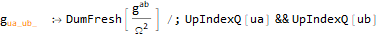

In [80]:
confRule2 = 
 RuleUnique[Metricg[ua_, ub_], \[CapitalOmega]^-2 Metricg[ua, ub], 
  UpIndexQ[ua] && UpIndexQ[ub]]

In [81]:
confRule = {confRule1, confRule2};

In [82]:
Metricg[la, lb] /. confRule

2
Ω  Metricg[la, lb]

등각 변환에 따른 크리스토플 심볼의 변환 공식:
$$
  \Gamma_{ab}^{\ \ \ c} \rightarrow \Gamma_{ab}^{\ \ \ c}
  + \delta_a^{\ c} \partial_b \ln\Omega
  + \delta_b^{\ c} \partial_a \ln\Omega
  - g_{ab} g^{cd} \partial_d \ln\Omega
$$

In [83]:
GammaCD[la, lb, uc]

GammaCD[la, lb, uc]

BD[la, Metricg[lb, ld]] Metricg[uc, ud]   BD[lb, Metricg[la, ld]] Metricg[uc, ud]
--------------------------------------- + --------------------------------------- - 
                   2                                         2
 
    BD[ld, Metricg[la, lb]] Metricg[uc, ud]
>   ---------------------------------------
                       2
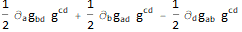

In [84]:
% // GammaToMetric

BD[la, Metricg[lb, ld]] Metricg[uc, ud]   BD[lb, Metricg[la, ld]] Metricg[uc, ud]
--------------------------------------- + --------------------------------------- - 
                   2                                         2
 
    BD[ld, Metricg[la, lb]] Metricg[uc, ud]
>   --------------------------------------- - 
                       2
 
    BD[ld, Ω] Metricg[la, lb] Metricg[uc, ud]
>   ----------------------------------------- + 
                        Ω
 
    BD[lb, Ω] Metricg[la, ld] Metricg[uc, ud]   BD[la, Ω] Metricg[lb, ld] Metricg[uc, ud]
>   ----------------------------------------- + -----------------------------------------
                        Ω                                           Ω
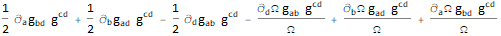

In [85]:
% /. confRule

BD[lb, Ω] Kdelta[uc, la]   BD[la, Ω] Kdelta[uc, lb]
GammaCD[la, lb, uc] + ------------------------ + ------------------------ - 
                                 Ω                          Ω
 
    BD[uc, Ω] Metricg[la, lb]
>   -------------------------
                Ω
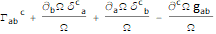

In [86]:
rhs = GammaCD[la, lb, uc] + %[[4]] + %[[5]] + %[[6]] // Absorbg

GammaCD[la_, lb_, uc_] :> 
 
                                   BD[lb, Ω] Kdelta[uc, la]   BD[la, Ω] Kdelta[uc, lb]
>   DumFresh[GammaCD[la, lb, uc] + ------------------------ + ------------------------ - 
                                              Ω                          Ω
 
       BD[uc, Ω] Metricg[la, lb]
>      -------------------------] /; DnIndexQ[la] && DnIndexQ[lb] && UpIndexQ[uc]
                   Ω
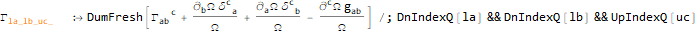

In [87]:
affineConfRule = 
 RuleUnique[GammaCD[la_, lb_, uc_], rhs, 
  DnIndexQ[la] && DnIndexQ[lb] && UpIndexQ[uc]]

BD[lb, Ω] Kdelta[uc, la]   BD[la, Ω] Kdelta[uc, lb]
GammaCD[la, lb, uc] + ------------------------ + ------------------------ - 
                                 Ω                          Ω
 
    BD[uc, Ω] Metricg[la, lb]
>   -------------------------
                Ω
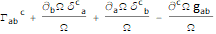

In [88]:
GammaCD[la, lb, uc] /. affineConfRule

*Normal* 좌표계에서
\begin{gather*}
  \partial_a g_{bc} = 0, \qquad
  \Gamma_{ab}^{\ \ \ c} = 0
\end{gather*}

In [89]:
affineZeroRule := {BD[d_, GammaCD[a_, b_, c_]] :> 
    BD[d, GammaCD[a, b, c]], GammaCD[a_, b_, c_] :> 0};
affineZeroRule

{BD[d_, GammaCD[a_, b_, c_]] :> BD[d, GammaCD[a, b, c]], GammaCD[a_, b_, c_] :> 0}

In [91]:
metricDerivZeroRule = BD[a_, Metricg[b_, c_]] :> 0

BD[a_, Metricg[b_, c_]] :> 0

In [92]:
normalCoordRule = Flatten[{affineZeroRule, metricDerivZeroRule}];

In [96]:
{BD[la, Metricg[lb, lc]], GammaCD[la, lb, uc], BD[la, GammaCD[lb, lc, ud]]}

{BD[la, Metricg[lb, lc]], GammaCD[la, lb, uc], BD[la, GammaCD[lb, lc, ud]]}

In [97]:
% /. normalCoordRule

{0, 0, BD[la, GammaCD[lb, lc, ud]]}

등각 변환에 따른 리치 텐서의 변환 공식:
\begin{align*}
  R_{ab} & \rightarrow R_{ab}
  - [(n-2) \delta_a^c \delta_b^d + g_{ab} g^{cd}]
  \Omega^{-1} \nabla_c \nabla_d \Omega \\
  & \quad + [2(n-2) \delta_a^c \delta_b^d - (n-3) g_{ab} g^{cd}]
  \Omega^{-2} (\nabla_c \Omega) (\nabla_d \Omega)
\end{align*}

In [98]:
expr1 = RicciCD[la, lb] // RiemannToGamma

-BD[la, GammaCD[lc, lb, uc]] + BD[lc, GammaCD[la, lb, uc]] - 
 
>   GammaCD[la, ld, uc] GammaCD[lc, lb, ud] + GammaCD[la, lb, ud] GammaCD[lc, ld, uc]

2 BD[la, Ω] BD[lb, Ω]   BD[lb, BD[la, Ω]]
-BD[la, GammaCD[lc, lb, uc]] - --------------------- + ----------------- + 
                                         2                     Ω
                                        Ω
 
                                  BD[la, Metricg[lc, lb]] BD[uc, Ω]
>   BD[lc, GammaCD[la, lb, uc]] + --------------------------------- - 
                                                  Ω
 
    BD[lc, Metricg[la, lb]] BD[uc, Ω]   BD[lc, Ω] GammaCD[la, lb, uc]
>   --------------------------------- - ----------------------------- - 
                    Ω                                 Ω
 
    BD[lb, Ω] GammaCD[la, lc, uc]   BD[lb, Ω] GammaCD[lc, la, uc]
>   ----------------------------- + ----------------------------- - 
                  Ω                               Ω
 
>   GammaCD[la, ld, uc] GammaCD[lc, lb, ud] + GammaCD[la, lb, ud] GammaCD[lc, ld, uc] - 
 
    BD[la, BD[lb, Ω]] Kdelta[uc, lc]   2 BD[la, Ω] BD[lb, Ω] Kdelta[uc, lc]
>   -------------------------------- + ------------------------------------ + 
                   Ω                                     2
                                                        Ω
 
    BD[lc, Ω] GammaCD[la, lb, uc] Kdelta[ud, ld]   BD[lc, BD[uc, Ω]] Metricg[la, lb]
>   -------------------------------------------- - --------------------------------- + 
                         Ω                                         Ω
 
    2 BD[lc, Ω] BD[uc, Ω] Metricg[la, lb]
>   ------------------------------------- - 
                      2
                     Ω
 
    BD[uc, Ω] GammaCD[ld, lc, ud] Metricg[la, lb]
>   --------------------------------------------- - 
                          Ω
 
    BD[lc, Ω] BD[uc, Ω] Kdelta[ud, ld] Metricg[la, lb]
>   -------------------------------------------------- + 
                             2
                            Ω
 
    BD[lb, Ω] BD[uc, Ω] Metricg[la, lc]
>   ----------------------------------- + 
                     2
                    Ω
 
    BD[uc, Ω] GammaCD[lc, lb, ud] Metricg[la, ld]
>   --------------------------------------------- - 
                          Ω
 
    BD[lb, Ω] BD[uc, Ω] Metricg[lc, la]   BD[la, BD[uc, Ω]] Metricg[lc, lb]
>   ----------------------------------- + --------------------------------- - 
                     2                                    Ω
                    Ω
 
    BD[la, Ω] BD[uc, Ω] Metricg[lc, lb]
>   ----------------------------------- - 
                     2
                    Ω
 
    BD[uc, Ω] BD[ud, Ω] Metricg[la, ld] Metricg[lc, lb]
>   --------------------------------------------------- - 
                             2
                            Ω
 
    BD[uc, Ω] GammaCD[la, lb, ud] Metricg[lc, ld]
>   --------------------------------------------- + 
                          Ω
 
    BD[uc, Ω] GammaCD[la, lc, ud] Metricg[ld, lb]
>   --------------------------------------------- + 
                          Ω
 
    BD[uc, Ω] BD[ud, Ω] Metricg[la, lb] Metricg[ld, lc]
>   ---------------------------------------------------
                             2
                            Ω
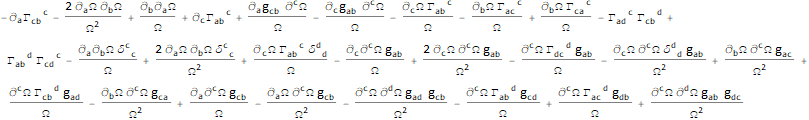

In [99]:
expr1 /. affineConfRule

2 BD[la, Ω] BD[lb, Ω]   BD[lb, BD[la, Ω]]
-BD[la, GammaCD[lc, lb, uc]] - --------------------- + ----------------- + 
                                         2                     Ω
                                        Ω
 
                                  BD[la, BD[lb, Ω]] Kdelta[uc, lc]
>   BD[lc, GammaCD[la, lb, uc]] - -------------------------------- + 
                                                 Ω
 
    2 BD[la, Ω] BD[lb, Ω] Kdelta[uc, lc]   BD[lc, BD[uc, Ω]] Metricg[la, lb]
>   ------------------------------------ - --------------------------------- + 
                      2                                    Ω
                     Ω
 
    2 BD[lc, Ω] BD[uc, Ω] Metricg[la, lb]
>   ------------------------------------- - 
                      2
                     Ω
 
    BD[lc, Ω] BD[uc, Ω] Kdelta[ud, ld] Metricg[la, lb]
>   -------------------------------------------------- + 
                             2
                            Ω
 
    BD[lb, Ω] BD[uc, Ω] Metricg[la, lc]   BD[lb, Ω] BD[uc, Ω] Metricg[lc, la]
>   ----------------------------------- - ----------------------------------- + 
                     2                                     2
                    Ω                                     Ω
 
    BD[la, BD[uc, Ω]] Metricg[lc, lb]   BD[la, Ω] BD[uc, Ω] Metricg[lc, lb]
>   --------------------------------- - ----------------------------------- - 
                    Ω                                    2
                                                        Ω
 
    BD[uc, Ω] BD[ud, Ω] Metricg[la, ld] Metricg[lc, lb]
>   --------------------------------------------------- + 
                             2
                            Ω
 
    BD[uc, Ω] BD[ud, Ω] Metricg[la, lb] Metricg[ld, lc]
>   ---------------------------------------------------
                             2
                            Ω
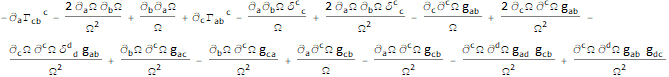

In [100]:
% /. normalCoordRule

4 BD[la, Ω] BD[lb, Ω]   BD[lb, BD[la, Ω]]
-BD[la, GammaCD[lc, lb, uc]] - --------------------- + ----------------- + 
                                         2                     Ω
                                        Ω
 
                                  BD[la, BD[lb, Ω]] Kdelta[uc, lc]
>   BD[lc, GammaCD[la, lb, uc]] - -------------------------------- + 
                                                 Ω
 
    2 BD[la, Ω] BD[lb, Ω] Kdelta[uc, lc]   BD[lc, BD[uc, Ω]] Metricg[la, lb]
>   ------------------------------------ - --------------------------------- + 
                      2                                    Ω
                     Ω
 
    2 BD[lc, Ω] BD[uc, Ω] Metricg[la, lb]   BD[ld, Ω] BD[ud, Ω] Metricg[la, lb]
>   ------------------------------------- + ----------------------------------- - 
                      2                                      2
                     Ω                                      Ω
 
    BD[lc, Ω] BD[uc, Ω] Kdelta[ud, ld] Metricg[la, lb]
>   -------------------------------------------------- + 
                             2
                            Ω
 
    BD[la, BD[uc, Ω]] Metricg[lc, lb]
>   ---------------------------------
                    Ω
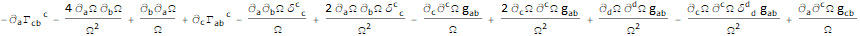

In [101]:
% // Absorbg

이하 생략

## 3.6 The Riemann and Related Rules

### 3.6.1 Organization of Rules

### 3.6.2 Automatic Riemann Rules

### 3.6.3 Riemann Rules Used with the ApplyRules Functions

### 3.6.4 Rules Used individually

### 3.6.5 Conversion Rules

Christoffel 심볼의 메트릭 표현:

In [102]:
GammaCD[la, lb, uc]

GammaCD[la, lb, uc]

BD[la, Metricg[lb, ld]] Metricg[uc, ud]   BD[lb, Metricg[la, ld]] Metricg[uc, ud]
--------------------------------------- + --------------------------------------- - 
                   2                                         2
 
    BD[ld, Metricg[la, lb]] Metricg[uc, ud]
>   ---------------------------------------
                       2
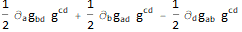

In [103]:
% // GammaToMetric

리만 텐서의 Christoffel 심볼 표현:

In [104]:
RiemannCD[la, lb, lc, ld]

RiemannCD[la, lb, lc, ld]

In [105]:
% // RiemannToGamma

-(GammaCD[la, le, ld] GammaCD[lb, lc, ue]) + GammaCD[la, lc, ue] GammaCD[lb, le, ld] - 
 
>   BD[la, GammaCD[lb, lc, ue]] Metricg[ld, le] + 
 
>   BD[lb, GammaCD[la, lc, ue]] Metricg[ld, le]

In [106]:
RicciCD[la, lb]

RicciCD[la, lb]

In [107]:
% // RiemannToGamma

-BD[la, GammaCD[lc, lb, uc]] + BD[lc, GammaCD[la, lb, uc]] - 
 
>   GammaCD[la, ld, uc] GammaCD[lc, lb, ud] + GammaCD[la, lb, ud] GammaCD[lc, ld, uc]

In [108]:
ScalarCD[]

ScalarCD[]

In [109]:
% // RiemannToGamma

GammaCD[la, ua, ub] GammaCD[lc, lb, uc] - GammaCD[la, lb, uc] GammaCD[lc, ua, ub] - 
 
>   BD[la, GammaCD[lb, lc, ub]] Metricg[ua, uc] + 
 
>   BD[la, GammaCD[lb, lc, ua]] Metricg[ub, uc]

In [122]:
Format[GetDimension[Latin]] = n;

Weyl 텐서와 리만 텐서의 관계:

In [114]:
WeylCD[la, lb, lc, ld]

WeylCD[la, lb, lc, ld]

Metricg[lb, ld] RicciCD[la, lc]    Metricg[lb, lc] RicciCD[la, ld]
-(-------------------------------) + ------------------------------- + 
              -2 + n                             -2 + n
 
    Metricg[la, ld] RicciCD[lb, lc]   Metricg[la, lc] RicciCD[lb, ld]
>   ------------------------------- - ------------------------------- + 
                -2 + n                            -2 + n
 
                                Metricg[la, ld] Metricg[lb, lc] ScalarCD[]
>   RiemannCD[la, lb, lc, ld] - ------------------------------------------ + 
                                            (-2 + n) (-1 + n)
 
    Metricg[la, lc] Metricg[lb, ld] ScalarCD[]
>   ------------------------------------------
                (-2 + n) (-1 + n)
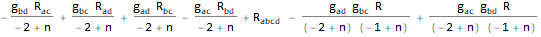

In [115]:
% // WeylToRiemann

In [116]:
% // RiemannToWeyl

WeylCD[la, lb, lc, ld]

Trace-Free 리치 텐서와 아인슈타인 텐서:

Metricg[la, lb] ScalarCD[]
RicciCD[la, lb] - --------------------------
                              n
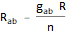

In [123]:
traceFreeRicci = 
 RicciCD[la, lb] - 1/GetDimension[Latin] Metricg[la, lb] ScalarCD[]

Kdelta[ua, la] ScalarCD[]
ScalarCD[] - -------------------------
                         n
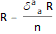

In [124]:
traceFreeRicci Metricg[ua, ub] // Absorbg

In [125]:
% /. Kdelta[ua, la] -> GetDimension[Latin]

0

In [126]:
einsteinG[a_, b_] := RicciCD[a, b] - 1/2 Metricg[a, b] ScalarCD[]

Metricg[la, lb] ScalarCD[]
RicciCD[la, lb] - --------------------------
                              2
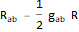

In [127]:
einsteinG[la, lb]

Christoffel 심볼 미분의 특별한 성질:

In [128]:
BD[la, GammaCD[lb, lc, uc]] - BD[lb, GammaCD[la, lc, uc]]

BD[la, GammaCD[lb, lc, uc]] - BD[lb, GammaCD[la, lc, uc]]

BD[la, Metricg[uc, ud]] BD[lb, Metricg[lc, ld]]
----------------------------------------------- - 
                       2
 
    BD[la, Metricg[lc, ld]] BD[lb, Metricg[uc, ud]]
>   -----------------------------------------------
                           2
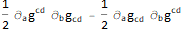

In [129]:
% // GammaToMetric // Tsimplify

-(BD[la, Metricg[le, lf]] BD[lb, Metricg[lc, ld]] Metricg[uc, ue] Metricg[ud, uf])
---------------------------------------------------------------------------------- + 
                                        2
 
    BD[la, Metricg[lc, ld]] BD[lb, Metricg[le, lf]] Metricg[uc, ue] Metricg[ud, uf]
>   -------------------------------------------------------------------------------
                                           2
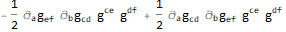

In [130]:
% /. BDinvgRule[]

In [131]:
% // Tsimplify

0

In [132]:
affineDRule = 
 RuleUnique[BD[la_, GammaCD[lb_, lc_, uc_]], 
  BD[lb, GammaCD[la, lc, uc]], 
  PairIndexQ[lc, uc] && ! IndexOrderedQ[{la, lb}]]

BD[la_, GammaCD[lb_, lc_, uc_]] :> 
 
>   DumFresh[BD[lb, GammaCD[la, l$120, u$120]]] /; 
 
>    PairIndexQ[lc, uc] && !IndexOrderedQ[{la, lb}]

In [133]:
BD[lb, GammaCD[la, lc, uc]]

BD[lb, GammaCD[la, lc, uc]]

In [134]:
% /. affineDRule

BD[la, GammaCD[lb, lc, uc]]

## 3.7 Using Contexts with MathTensor

In [135]:
MakeConstantMetric[]

In [136]:
BD[la, Metricg[lb, lc]]

0

In [137]:
MakeConstantMetric[{-1, 1, 1}]

-1   0    0

0    1    0

0    0    1
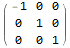

In [138]:
Table[Metricg[-i, -j], {i, 3}, {j, 3}] // MatrixForm

In [139]:
Epsilon[-1, -2, -3]

1